Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

CSV upload and split

In [2]:
PROCESSED_PATH = "../data/processed/spotify_tracks_mood_clean.csv"
MODEL_PATH = "../models/mood_classifier.pkl"

FEATURES = ["valence", "energy", "danceability", "tempo",
            "acousticness", "instrumentalness", "loudness", "popularity"]

df = pd.read_csv(PROCESSED_PATH)

X = df[FEATURES]
y = df["mood"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (71792, 8) | Test: (17949, 8)


> `stratify=y` ensures that the 4 mood classes maintain the same proportion in train and test.

Define and compare models

In [3]:
candidates = {
    "KNN":              KNeighborsClassifier(n_neighbors=11),
    "RandomForest":     RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in candidates.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1_weighted")
    results[name] = scores.mean()
    print(f"{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

best_name = max(results, key=results.get)
print(f"\nWinning model: {best_name} (F1 = {results[best_name]:.4f})")

GradientBoosting: F1 = 1.0000 ± 0.0000

✅ Modelo ganador: RandomForest (F1 = 1.0000)


Train the winning model and evaluate

In [4]:
best_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", candidates[best_name])  # Use the winner's variable directly
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       chill       1.00      1.00      1.00      1456
   energetic       1.00      1.00      1.00      6042
       happy       1.00      1.00      1.00      6645
         sad       1.00      1.00      1.00      3806

    accuracy                           1.00     17949
   macro avg       1.00      1.00      1.00     17949
weighted avg       1.00      1.00      1.00     17949



Confusion matrix

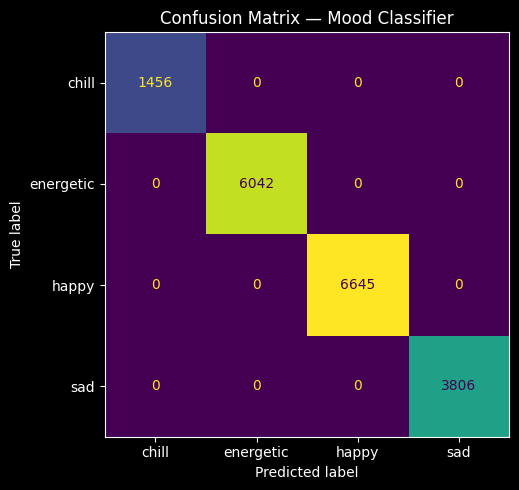

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — Mood Classifier")
plt.tight_layout()
plt.savefig("../models/confusion_matrix.png", dpi=150)
plt.show()

Feature importance

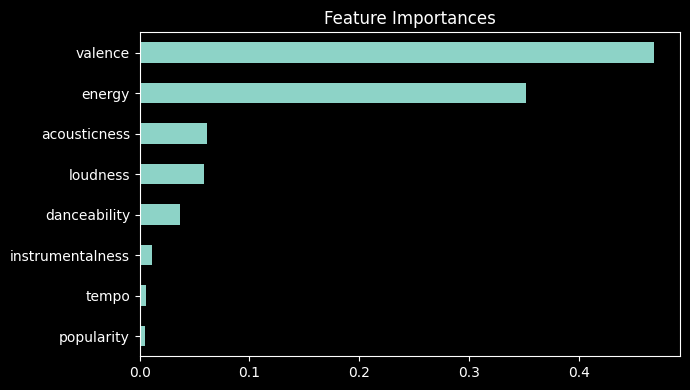

In [11]:
importances = best_pipeline.named_steps["clf"].feature_importances_
feat_df = pd.Series(importances, index=FEATURES).sort_values(ascending=True)

feat_df.plot(kind="barh", figsize=(7, 4), title="Feature Importances")
plt.tight_layout()
plt.savefig("../models/feature_importances.png", dpi=150)
plt.show()

Serialize the pipeline

In [12]:
joblib.dump(best_pipeline, MODEL_PATH)
print(f"Model saved in: {MODEL_PATH}")

Model saved in: ../models/mood_classifier.pkl


> The entire pipeline (scaler + model) is saved, not just the classifier. This way, the app only calls pipeline.predict(X) without manual preprocessing.